# CAP 6619 Deep Learning, Dense Layer image classification
### Dog vs. cat classification
    Brandon Sanford
    7th October, 2026
    CAP 6619                      
    Original by X. Zhu, 09/30/2026



### The latest version of Tensor Flow (2.16+) is used, with native Keras 3
Note: An Anaconda enviornment was created for this notebook, including:

- python 3.11.17
- TensorFlow 2.21.0
- Numpy (downgraded to <2.0, like 1.23.5)
- Matplotlib
- scikit-learn
- scikeras
- ipykernel

- cudatoolkit=11.2 (NVIDA GPU acceleration)
- cudnn=8.1.0 (NVIDA Deep Neural Network CUDA Library)

In [44]:
# imports
from os import listdir
from numpy import asarray, save
import numpy as np

# import tensorflow and keras
import tensorflow as tf
from tensorflow import keras

# For tensorflow 2.9.0 or later, load_img etc moved to keras.utils
# Image utilities and layers from tensorflow.keras
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.layers import (
    BatchNormalization,
    Activation,
    Flatten,
    Dense,
    Dropout
)
from tensorflow.keras import models, layers

# plot dog photos from the dogs vs cats dataset
from matplotlib import pyplot as plt
from matplotlib.image import imread

# split data into training and testing datasets
from sklearn.model_selection import train_test_split

# For 10-Fold Cross validation, SciKeras can be used
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import cross_val_score

## Accessing dogsvscat1000 folder

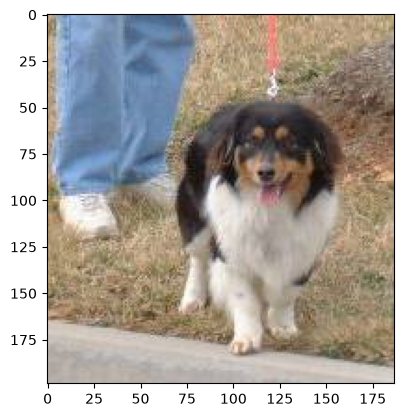

In [45]:
folder='dogvscat1000/'
# show one image
filename = folder + 'dog.' + '2' + '.jpg'
# load image pixels
image = imread(filename)
# plot raw pixel data
plt.imshow(image)

## Other Vizualizations

In [46]:
# function definitions for displaying images
def displayImages(foldername,dogorcat,startID):
    # plot first few images
    for i in range(9):
        #define subplot 3x3
        plt.subplot(330 + 1 + i)
        # define filename
        filename = foldername + dogorcat +'.' + str(i+startID) + '.jpg'
        # load image pixels
        image = imread(filename)
        # plot raw pixel data
        plt.imshow(image)
        # show the figure
plt.show()

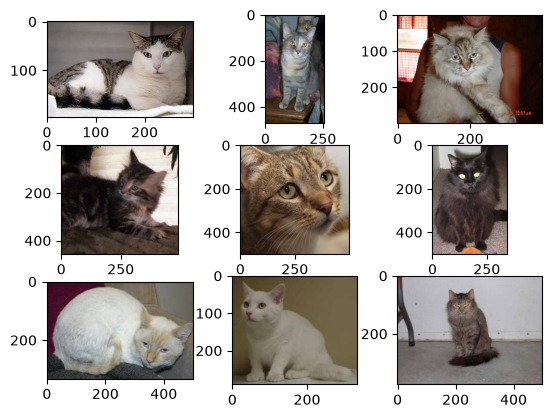

In [47]:
# Vizualizaing cats
displayImages(folder,"cat",50)

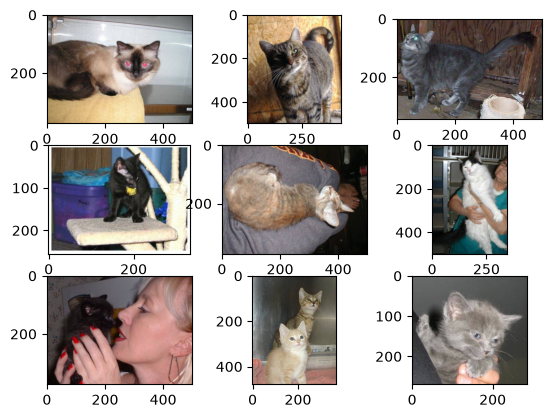

In [48]:
displayImages(folder,"cat",20)

In [49]:
# define location of dataset
folder = 'dogvscat1000/'
photos, labels = list(), list()
# enumerate files in the directory
for file in listdir(folder):
    # determine class
    output = 0.0
    if file.startswith('cat'):
        output = 1.0
        # load image
    photo = load_img(folder + file, target_size=(64, 64),color_mode="rgb")  #"rgb" for color mode; "grayscale"
    # convert to numpy array
    photo = img_to_array(photo)
    # store
    photos.append(photo)
    labels.append(output)
# convert to a numpy arrays
photos = asarray(photos)
labels = asarray(labels)
print(photos.shape, labels.shape)
# save the reshaped photos
save('dogs_vs_cats_photos.npy', photos)
save('dogs_vs_cats_labels.npy', labels)

(1000, 64, 64, 3) (1000,)


In [50]:
print(photos[1].shape)

(64, 64, 3)


## Analysis - performing data split into training and test sets

A 60/40 split is made, with 60% of the dataset dedicated to training and 40% to testing.

In [51]:
X_train, X_test, y_train, y_test = train_test_split(photos, labels, test_size=.4, random_state=42)

Declaring the Neural Network Model - Define as a function

In [52]:
def build_nn_model(hidden_1_af:str, hidden_2_af: str, output_af:str):
    """A function for creating a Feed Foward Nerual Network model with one input layer, one output
    layer, and two hidden layers. activation functions can be set for each hidden layer as well as the 
    output layer. Input layer parameters are fixed by default for this notebook example.
    
    """
    # Declare Nerual Network (NN) model (using shortened version - no long keras).
    NN_model = keras.Sequential()
    # Flatten layers for input shape
    NN_model.add(layers.Flatten(input_shape=(64, 64, 3),name="Input"))

    # Hidden Layer 1
    NN_model.add(layers.Dense(256, activation=hidden_1_af,name="Hidden_1", kernel_regularizer=keras.regularizers.l2(0.01)))
    NN_model.add(layers.Dropout(rate=0.5))

    # Hidden Layer 2
    NN_model.add(layers.Dense(128, activation=hidden_2_af, name="Hidden_2"))

    # Output layer - Softmax will be explored
    NN_model.add(layers.Dense(2, activation=output_af, name="Output"))

    # Compile the model
    NN_model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

    return NN_model

### Using SciKeras for 10-Fold Cross Validation 

SciKeras is a wrapper for scikit-learn functions reltaed to Keras models in tensorflow (i.e., Keras API). Rather than create a 10-Fold Cross Validation funciton from scratch, the wrapper can be used with the `build_nn_model` function for a given training instance.

Sources:

- https://pypi.org/project/scikeras/
- https://keras.io/examples/vision/image_classification_from_scratch/

An issue that arises is that KerasClassifier does not record the past loss and accuracy scores for each epoch as would be done with a traditioanl Cross-Validation funciton made from sctratch. Still, a custom callback function can be used to essentially retrieve the 'history' of the past loss and accuracy values for KerasClassifier for all 10-folds.

Define Callback class module

In [53]:
from tensorflow.keras.callbacks import Callback

class History_CB(Callback):
    """A Callback class module to record histories for loss and accuracy for 10-Fold Cross validation realted
    to Keras's KerasClassifier"""

    # Initialize an array to hold call back histories for all 10-Folds - Appends every new fold's callback
    saved_history=[] 
    
    def __init__(self):
        super().__init__()
        self.epoch_loss=[] # container for recorded epoch losses
        self.epoch_accuracy=[] # container for recorded epoch accuracy

        # Append new flds of instance to the saved_history array per class module call.
        History_CB.saved_history.append(self)


    def on_epoch_end(self, epoch, logs=None):
        """A function that appends recorged loss and accuracy for each epoch"""
        logs = logs or {}
        self.epoch_loss.append(logs.get('loss'))
        self.epoch_accuracy.append(logs.get('accuracy'))

Define a function definition to initialize callbacks per fold and record the history of loss and accuracy.

In [54]:
# def get_history_CB():
#     """A function that calls the History class module"""
#     cb = History_CB()
#     saved_history.append(cb)
#     return cb

Use KerasClassifier with 10-Fold Cross Validation

Epoch 1/15


c:\Users\Sapph\anaconda3\envs\tf_latest\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4800 - loss: 648.1703
Epoch 2/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5256 - loss: 188.8126
Epoch 3/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5122 - loss: 28.2710
Epoch 4/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5333 - loss: 6.5466
Epoch 5/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5389 - loss: 5.8352
Epoch 6/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5444 - loss: 5.6313
Epoch 7/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5656 - loss: 5.5398
Epoch 8/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5567 - loss: 5.5011
Epoch 9/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5589 - loss: 5.3615
Epoch 10/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5589 - loss: 5.3016
Epoch 11/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5667 - loss: 5.2237
Epoch 12/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.562

c:\Users\Sapph\anaconda3\envs\tf_latest\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5211 - loss: 531.7994
Epoch 2/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4900 - loss: 337.5145
Epoch 3/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4778 - loss: 111.1588
Epoch 4/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5311 - loss: 7.9740
Epoch 5/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5444 - loss: 6.1662
Epoch 6/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5222 - loss: 6.0963
Epoch 7/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5511 - loss: 5.7036
Epoch 8/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5556 - loss: 5.5979
Epoch 9/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5433 - loss: 5.5641
Epoch 10/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5500 - loss: 5.4560
Epoch 11/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5522 - loss: 5.3733
Epoch 12/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.55

...

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4878 - loss: 912.3968
Epoch 2/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4944 - loss: 262.4511
Epoch 3/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5078 - loss: 47.2061
Epoch 4/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4867 - loss: 12.4298
Epoch 5/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5589 - loss: 5.8049
Epoch 6/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5567 - loss: 5.6872
Epoch 7/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5556 - loss: 5.6130
Epoch 8/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5567 - loss: 5.5290
Epoch 9/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5567 - loss: 5.4531
Epoch 10/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5556 - loss: 5.3795
Epoch 11/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5556 - loss: 5.3076
Epoch 12/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.55

c:\Users\Sapph\anaconda3\envs\tf_latest\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4911 - loss: 562.9044
Epoch 2/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4900 - loss: 203.7187
Epoch 3/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5278 - loss: 44.9964
Epoch 4/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5467 - loss: 6.5125
Epoch 5/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5578 - loss: 5.7504
Epoch 6/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5544 - loss: 5.5219
Epoch 7/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5589 - loss: 5.4431
Epoch 8/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5544 - loss: 5.3699
Epoch 9/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5578 - loss: 5.2911
Epoch 10/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5578 - loss: 5.2852
Epoch 11/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5600 - loss: 5.1548
Epoch 12/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.555

c:\Users\Sapph\anaconda3\envs\tf_latest\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5111 - loss: 614.8796
Epoch 2/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4900 - loss: 291.7561
Epoch 3/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5233 - loss: 42.1625
Epoch 4/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4422 - loss: 6.1965
Epoch 5/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5144 - loss: 5.7809
Epoch 6/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5589 - loss: 5.7145
Epoch 7/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5578 - loss: 5.6519
Epoch 8/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5567 - loss: 5.5903
Epoch 9/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5567 - loss: 5.5290
Epoch 10/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5556 - loss: 5.4696
Epoch 11/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5578 - loss: 5.4086
Epoch 12/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.556

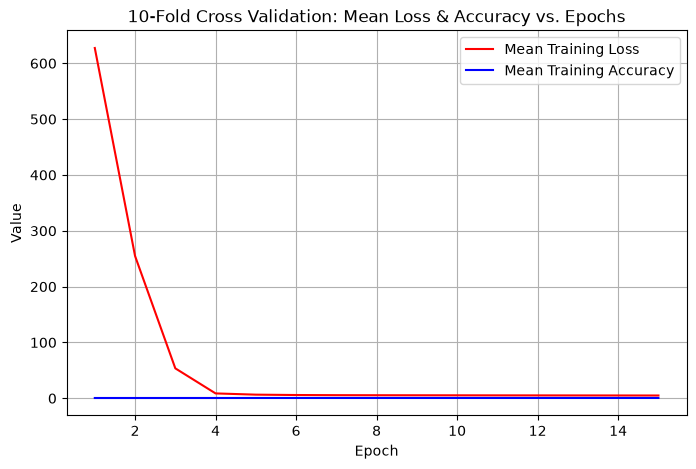

In [55]:
# specify epoches
epoch_num = 15

cross_val = KerasClassifier(
    
    model=build_nn_model, 
    hidden_1_af='relu',
    hidden_2_af='relu',
    output_af='softmax',
    epochs=epoch_num, 
    batch_size=32, 
    callbacks=[History_CB], # use callback function to get history
    verbose=1) # verbose=1 outputs the epoch and loss number.

# Perform 10-Fold Cross VAlidation
cv_scores = cross_val_score(cross_val, photos, labels, cv=10) # Performs 10-Fold Cross Validation

print(f"10-Fold Cross Validation Accuracy (mean): {cv_scores.mean(): .4f}")
print(f"10-Fold Cross Validation Acccuracy (std): {cv_scores.std(): .4f}")

# Extract recorded losses and accuracies from all 10-Folds for plotting via list comprehensions
total_losses = [cb.epoch_loss for cb in History_CB.saved_history]
total_accuracy = [cb.epoch_accuracy for cb in History_CB.saved_history]

# Evaluate mean for all 10 folds per epoch for loss and accuracy 
mean_loss = np.mean(total_losses, axis=0)
mean_accuracy = np.mean(total_accuracy, axis=0)

# Specify Epoch Range for plotting 
epoch_range = range(1, epoch_num + 1)

##### Plot Mean Loss and Mean Accuracy vs Epochs

plt.figure(figsize=(8, 5))
plt.plot(epoch_range, mean_loss, 'r-', label='Mean Training Loss')
plt.plot(epoch_range, mean_accuracy, 'b-', label='Mean Training Accuracy')

plt.title('10-Fold Cross Validation: Mean Loss & Accuracy vs. Epochs')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()


Here, with a mean of 0.0140 and a standard deviation of 0.0140 and 0.0136 repectively, along with a low training accuracy line, the model is rather poor performing. this coudld be due to the model parameters explored, namely softmax, which results binary outputs, and issyues with the model like sparse categorical corss entropy.the learning rate for ADAM could also be reduced to allow for less ossciliating steps. Another solution is to noramlized the input photos

Fixes to model implimented. a new model function definition is called

In [60]:

# Ensure pixel values are scaled before passing into cross_val_score
photos_normalized = photos / 255.0  

def build_nn_model_2(hidden_1_af='leaky_relu', hidden_2_af='leaky_relu', output_af=None):
    NN_model = keras.Sequential()
    NN_model.add(layers.Flatten(input_shape=(64, 64, 3), name="Input"))

    # Reduce L2 penalty to stop early optimization bottlenecking
    NN_model.add(layers.Dense(256, activation=hidden_1_af, name="Hidden_1", 
                             kernel_regularizer=keras.regularizers.l2(1e-4)))
    NN_model.add(layers.Dropout(rate=0.3))  # Slightly lower dropout rate

    NN_model.add(layers.Dense(128, activation=hidden_2_af, name="Hidden_2"))

    # # Option A for output: 2-neuron output with Linear activation (from_logits=True)
    # NN_model.add(layers.Dense(2, activation=output_af, name="Output"))

    # Option B for output: Single neuron binary classification (especially for binary labels)
    NN_model.add(layers.Dense(1, activation='sigmoid', name="Output"))

    NN_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), # Lower learning rate
        # loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), # Use from_logits=True with linear output
        loss='binary_crossentropy', # Use if using Option B
        metrics=['accuracy']
    )

    return NN_model

Epoch 1/20


c:\Users\Sapph\anaconda3\envs\tf_latest\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4944 - loss: 48.3306
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5344 - loss: 16.7688
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5244 - loss: 9.4724
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5322 - loss: 6.8103
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5111 - loss: 3.1327
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4944 - loss: 1.4183
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4900 - loss: 0.8070
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5611 - loss: 0.7371
Epoch 9/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5756 - loss: 0.7198
Epoch 10/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5711 - loss: 0.7153
Epoch 11/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5744 - loss: 0.7060
Epoch 12/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5711 -

c:\Users\Sapph\anaconda3\envs\tf_latest\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5133 - loss: 57.5143
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5300 - loss: 30.5189
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5156 - loss: 25.7022
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5322 - loss: 16.4270
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5278 - loss: 8.4094
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5133 - loss: 4.7521
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5167 - loss: 2.6848
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5056 - loss: 0.9161
Epoch 9/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5711 - loss: 0.7367
Epoch 10/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5733 - loss: 0.7476
Epoch 11/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5800 - loss: 0.7455
Epoch 12/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5767

...

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.4978 - loss: 41.8644
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5344 - loss: 21.5345
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4956 - loss: 14.9343
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4978 - loss: 10.9501
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5289 - loss: 4.0432
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5567 - loss: 2.1000
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5400 - loss: 0.8422
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5578 - loss: 0.7571
Epoch 9/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5700 - loss: 0.7167
Epoch 10/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5844 - loss: 0.7177
Epoch 11/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5756 - loss: 0.7121
Epoch 12/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5889

c:\Users\Sapph\anaconda3\envs\tf_latest\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5178 - loss: 69.5736
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4833 - loss: 32.6662
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5167 - loss: 19.3192
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4956 - loss: 12.4624
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5378 - loss: 7.4672
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5244 - loss: 2.4213
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5022 - loss: 0.8818
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5578 - loss: 0.7378
Epoch 9/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5578 - loss: 0.7302
Epoch 10/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5533 - loss: 0.7265
Epoch 11/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5578 - loss: 0.7274
Epoch 12/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5578

c:\Users\Sapph\anaconda3\envs\tf_latest\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5133 - loss: 54.1583
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5322 - loss: 24.3472
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5256 - loss: 20.2042
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.4856 - loss: 12.7634
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5244 - loss: 4.5294
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5133 - loss: 0.9573
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5456 - loss: 0.7563
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5122 - loss: 0.7299
Epoch 9/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5389 - loss: 0.7376
Epoch 10/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5578 - loss: 0.7363
Epoch 11/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5356 - loss: 0.7406
Epoch 12/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5578

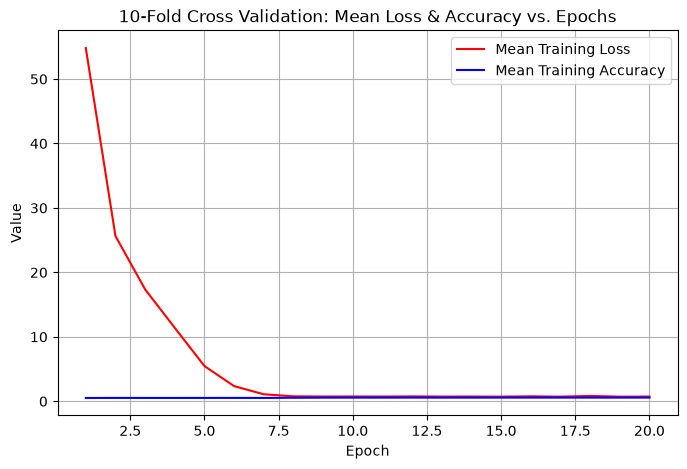

In [61]:
# increase number of epoches to 20
epoch_num = 20

cross_val = KerasClassifier(
    
    model=build_nn_model_2, 
    hidden_1_af='relu',
    hidden_2_af='relu',
    output_af='softmax',
    epochs=epoch_num, 
    batch_size=32, 
    callbacks=[History_CB], # use callback function to get history
    verbose=1) # verbose=1 outputs the epoch and loss number.

# Clear previous run's history accumulation before restarting CV
History_CB.saved_history = []

# Perform 10-Fold Cross VAlidation
cv_scores = cross_val_score(cross_val, photos, labels, cv=10) # Performs 10-Fold Cross Validation

print(f"10-Fold Cross Validation Accuracy (mean): {cv_scores.mean(): .4f}")
print(f"10-Fold Cross Validation Acccuracy (std): {cv_scores.std(): .4f}")

# Extract recorded losses and accuracies from all 10-Folds for plotting via list comprehensions
total_losses = [cb.epoch_loss for cb in History_CB.saved_history]
total_accuracy = [cb.epoch_accuracy for cb in History_CB.saved_history]

# Evaluate mean for all 10 folds per epoch for loss and accuracy 
mean_loss = np.mean(total_losses, axis=0)
mean_accuracy = np.mean(total_accuracy, axis=0)

# Specify Epoch Range for plotting 
epoch_range = range(1, epoch_num + 1)

##### Plot Mean Loss and Mean Accuracy vs Epochs

plt.figure(figsize=(8, 5))
plt.plot(epoch_range, mean_loss, 'r-', label='Mean Training Loss')
plt.plot(epoch_range, mean_accuracy, 'b-', label='Mean Training Accuracy')

plt.title('10-Fold Cross Validation: Mean Loss & Accuracy vs. Epochs')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()
